In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/hashes.txt
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/database.sqlite


# Amazon Fine Food Reviews — Sentiment Analysis Pipeline
**Refactored from original Kaggle notebook**  
*VADER vs RoBERTa | 3-class: Negative / Neutral / Positive*  
Target: `score < 3 → Negative` | `score == 3 → Neutral` | `score > 3 → Positive`


## 0. Configuration
Single source of truth for all parameters. Change here, propagates everywhere.

In [6]:
import os

CONFIG = {
    # ── Data ─────────────────────────────────────────────────
    "data_path": os.getenv("DATA_PATH", "/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv"),
    "sample_size": int(os.getenv("SAMPLE_SIZE", 5000)),  # None = full dataset

    # ── Labels ───────────────────────────────────────────────
    "label_map": {1: "Negative", 2: "Negative", 3: "Neutral", 4: "Positive", 5: "Positive"},
    # Assignment target: score<3 → Neg, score=3 → Neu, score>3 → Pos
    "target_map": "assignment",  # uses map_true_score()

    # ── VADER thresholds (standard practice) ─────────────────
    "vader_pos_threshold":  0.05,
    "vader_neg_threshold": -0.05,

    # ── RoBERTa ───────────────────────────────────────────────
    "roberta_model": "cardiffnlp/twitter-roberta-base-sentiment",
    "roberta_max_len": 512,   # tokenizer hard limit

    # ── Artefact paths ────────────────────────────────────────
    "results_path":      "results_df.csv",
    "report_vader_path": "report_vader.json",
    "report_roberta_path": "report_roberta.json",
}


In [7]:
import logging
import json
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.metrics import classification_report, confusion_matrix
from wordcloud import WordCloud

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger(__name__)

plt.style.use("ggplot")
C = {"Positive": "#4CAF50", "Neutral": "#FF9800", "Negative": "#F44336", "bar": "#5C85D6"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

nltk.download("vader_lexicon",       quiet=True)
nltk.download("punkt",               quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)

logger.info("Setup complete.")


20:17:57 | INFO | Setup complete.


In [8]:
def ingest_data(data_path: str, sample_size: int | None = None) -> pd.DataFrame:
    """
    Load Reviews.csv and optionally sample rows.
    Adapted from original notebook cell 7 / cell 60.

    Args:
        data_path:   path to Reviews.csv
        sample_size: if set, take the first N rows (mirrors original head(5000))
    Returns:
        Raw DataFrame
    """
    logger.info(f"Loading data from: {data_path}")
    df = pd.read_csv(data_path)

    if sample_size:
        df = df.head(sample_size)
        logger.info(f"Sampled to {len(df):,} rows (sample_size={sample_size})")
    else:
        logger.info(f"Full dataset loaded: {len(df):,} rows")

    logger.info(f"Columns: {list(df.columns)}")
    return df


In [9]:

data = ingest_data(CONFIG["data_path"], sample_size=CONFIG["sample_size"])
data.head()


20:18:01 | INFO | Loading data from: /kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv
20:18:07 | INFO | Sampled to 5,000 rows (sample_size=5000)
20:18:07 | INFO | Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## 3. Exploratory Data Analysis
Preserved from the original notebook. Three panels: Ratings & Sentiment, Text Analysis,
Helpfulness & Correlations.


In [10]:
def plot_ratings_and_sentiment(df: pd.DataFrame) -> None:
    """
    Panel 1 — Ratings & Sentiment (original notebook cells 13–14).
    Plots: score distribution, sentiment pie, avg score/year, volume/year.
    """
    sentiment_series = df["Score"].map({1: "Negative", 2: "Negative",
                                        3: "Neutral", 4: "Positive", 5: "Positive"})
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle("Ratings & Sentiment", fontsize=14, fontweight="bold")

    # Score distribution
    ax = axes[0, 0]
    counts = df["Score"].value_counts().sort_index()
    ax.bar(counts.index, counts.values,
           color=[C["Negative"], C["Negative"], C["Neutral"], C["Positive"], C["Positive"]],
           edgecolor="white")
    ax.set(title="Score Distribution", xlabel="Star Rating", ylabel="Count")

    # Sentiment pie — using assignment mapping: <3=Neg, =3=Neu, >3=Pos
    ax = axes[0, 1]
    assign_sentiment = df["Score"].apply(
        lambda s: "Negative" if s < 3 else ("Neutral" if s == 3 else "Positive")
    )
    s_counts = assign_sentiment.value_counts().reindex(["Positive", "Neutral", "Negative"])
    ax.pie(s_counts, labels=s_counts.index, autopct="%1.1f%%",
           colors=[C["Positive"], C["Neutral"], C["Negative"]], startangle=140)
    ax.set_title("Sentiment Split (Assignment Labels)")

    # Avg score per year
    ax = axes[1, 0]
    years = pd.to_datetime(df["Time"], unit="s").dt.year
    yr_avg = df.groupby(years)["Score"].mean()
    ax.plot(yr_avg.index, yr_avg.values, marker="o", color=C["bar"])
    ax.axhline(df["Score"].mean(), color=C["Negative"], linestyle="--",
               label=f"Avg: {df['Score'].mean():.2f}")
    ax.set(title="Avg Score per Year", xlabel="Year", ylabel="Avg Score")
    ax.legend()

    # Review volume per year
    ax = axes[1, 1]
    years.value_counts().sort_index().plot(kind="bar", ax=ax, color=C["bar"])
    ax.set(title="Review Volume per Year", xlabel="Year", ylabel="Count")

    plt.tight_layout()
    plt.show()
    logger.info("Ratings & Sentiment panel rendered.")


In [11]:
def plot_text_analysis(df: pd.DataFrame) -> None:
    """
    Panel 2 — Text Analysis (original notebook cell 17).
    Plots: length distribution, avg length by score, word count boxplot, wordcloud.
    """
    sentiment_series = df["Score"].apply(
        lambda s: "Negative" if s < 3 else ("Neutral" if s == 3 else "Positive")
    )
    lengths = df["Text"].str.len()
    word_counts = df["Text"].apply(lambda x: len(str(x).split()))

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle("Text Analysis", fontsize=14, fontweight="bold")

    axes[0, 0].hist(lengths, bins=30, color=C["bar"], edgecolor="white")
    axes[0, 0].set(title="Review Length (Chars)", xlabel="Length")

    avg_len = lengths.groupby(df["Score"]).mean()
    axes[0, 1].bar(avg_len.index, avg_len.values, color=C["bar"])
    axes[0, 1].set(title="Avg Length by Score", xlabel="Score", ylabel="Avg Chars")

    sns.boxplot(x=sentiment_series, y=word_counts,
                order=["Positive", "Neutral", "Negative"],
                palette=[C["Positive"], C["Neutral"], C["Negative"]],
                ax=axes[1, 0])
    axes[1, 0].set(title="Word Count by Sentiment", ylim=(0, 400))

    wc = WordCloud(background_color="white", colormap="Blues").generate(
        " ".join(df["Summary"].dropna())
    )
    axes[1, 1].imshow(wc); axes[1, 1].axis("off")
    axes[1, 1].set_title("Summary WordCloud")

    plt.tight_layout()
    plt.show()
    logger.info("Text Analysis panel rendered.")


In [12]:
def plot_helpfulness_correlations(df: pd.DataFrame) -> None:
    """
    Panel 3 — Helpfulness & Correlations (original notebook cell 20).
    Plots: top 10 products, correlation heatmap.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    df["ProductId"].value_counts().head(10).plot(kind="barh", color=C["bar"], ax=axes[0])
    axes[0].set_title("Top 10 Reviewed Products")

    temp_corr = pd.DataFrame({
        "Score":       df["Score"],
        "Helpfulness": df["HelpfulnessNumerator"] / df["HelpfulnessDenominator"].replace(0, 1),
        "Len":         df["Text"].str.len(),
        "Words":       df["Text"].apply(lambda x: len(str(x).split())),
    })
    sns.heatmap(temp_corr.corr(), annot=True, cmap="coolwarm", ax=axes[1])
    axes[1].set_title("Correlation Matrix")

    plt.tight_layout()
    plt.show()
    logger.info("Helpfulness & Correlations panel rendered.")


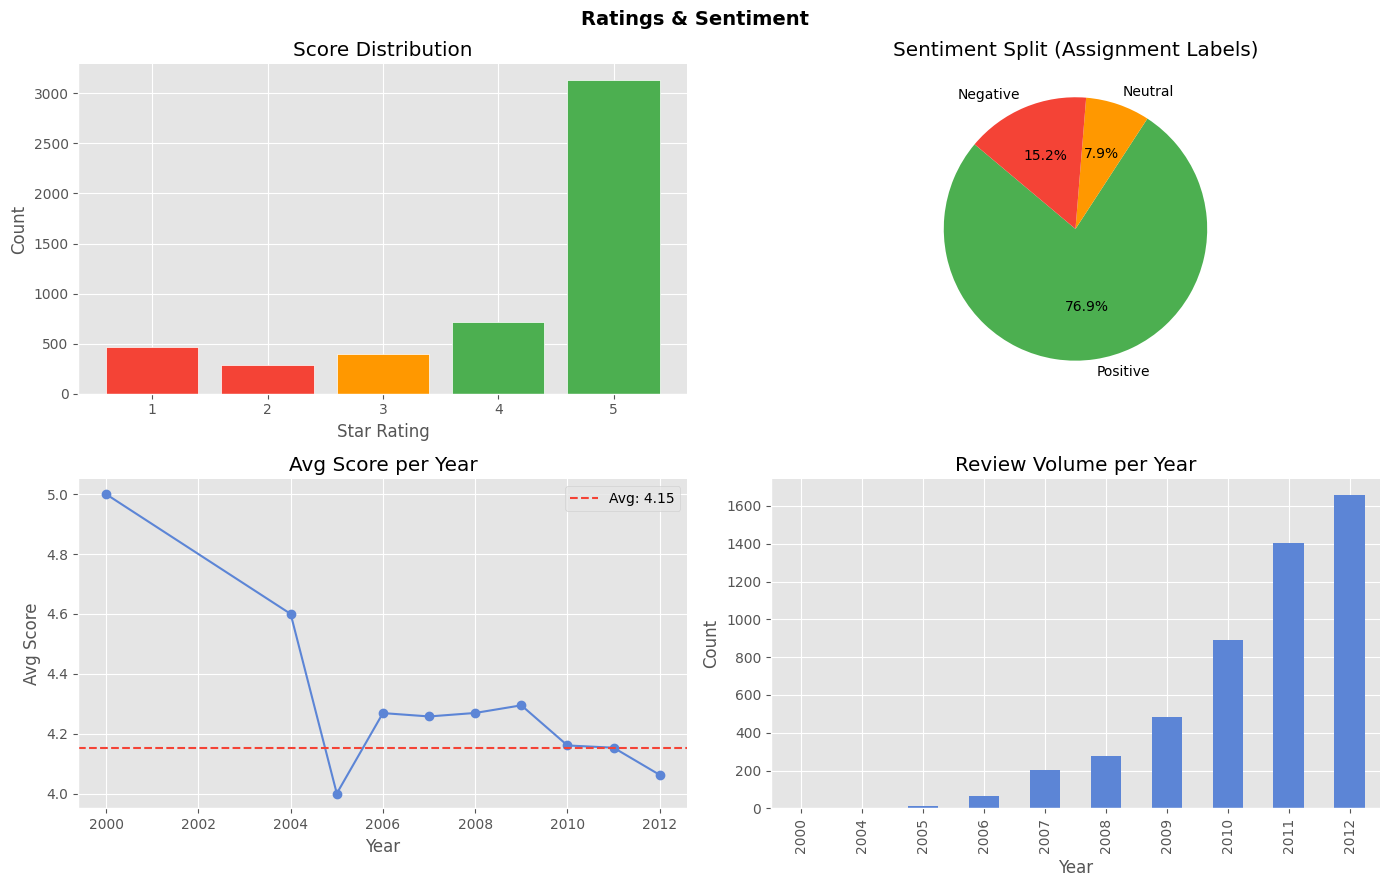

20:20:13 | INFO | Ratings & Sentiment panel rendered.


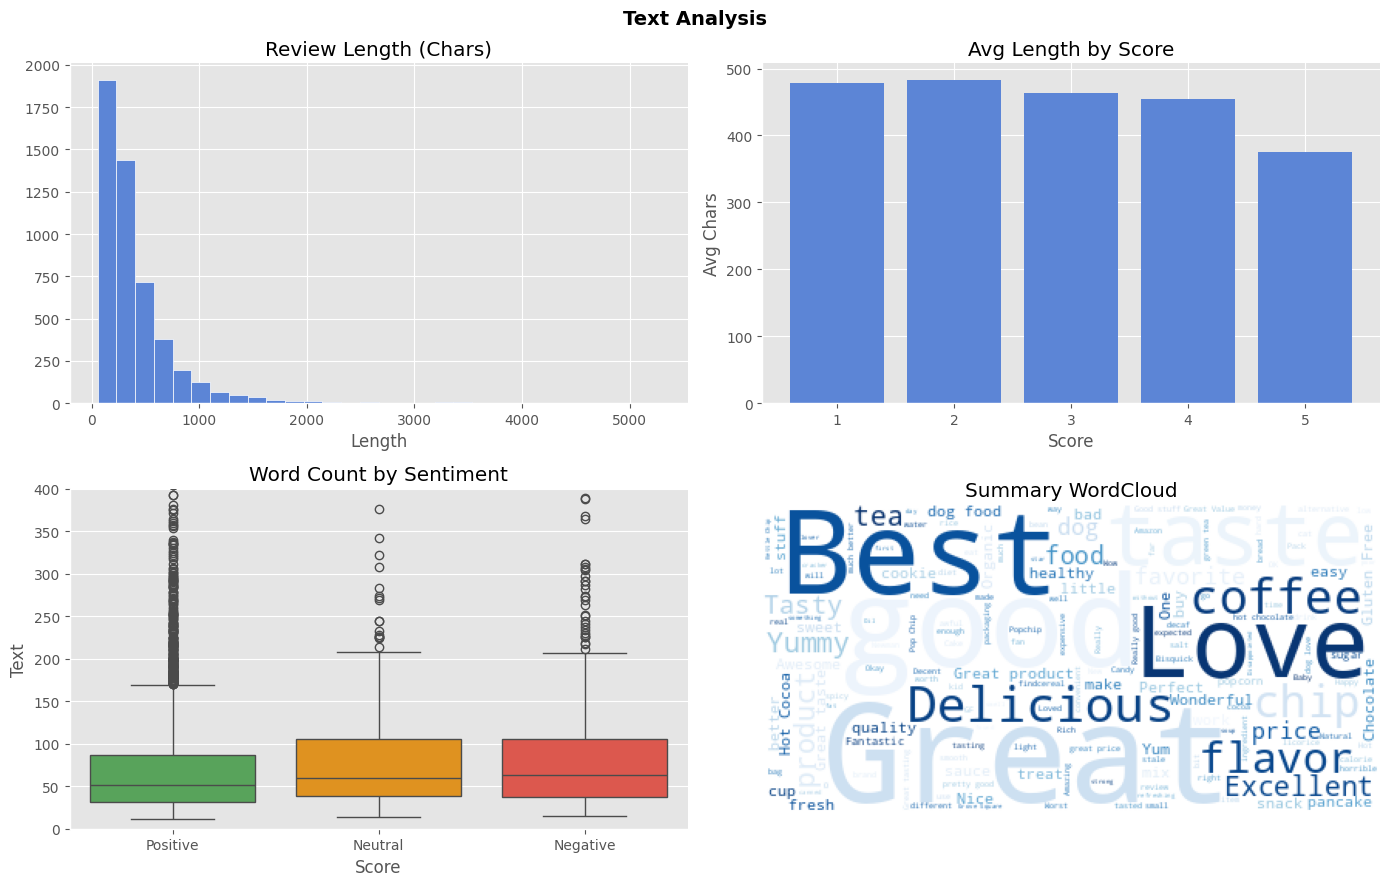

20:20:14 | INFO | Text Analysis panel rendered.


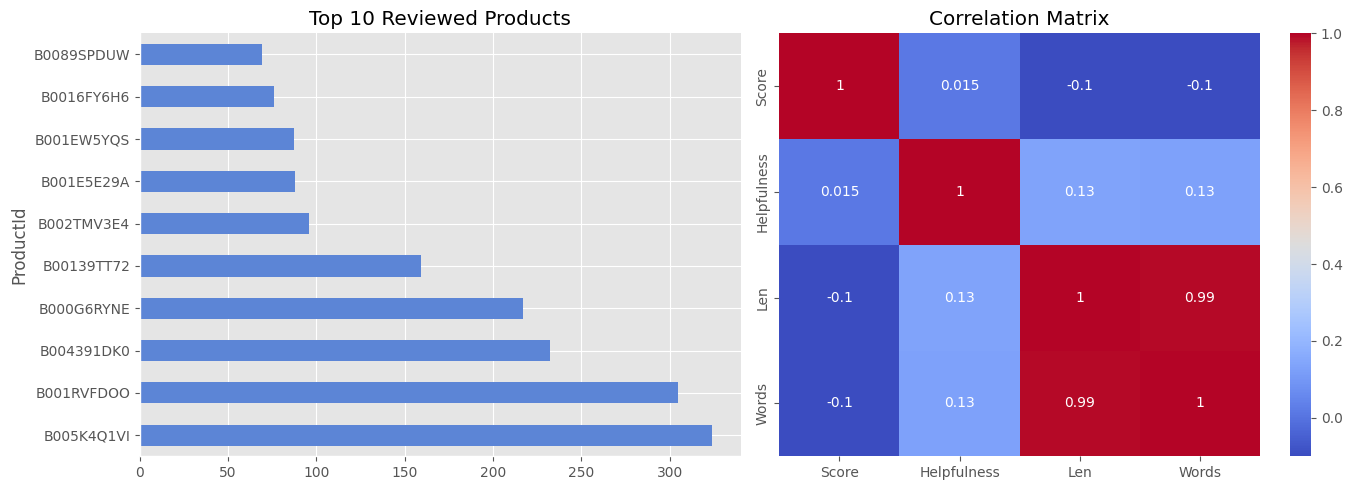

20:20:14 | INFO | Helpfulness & Correlations panel rendered.


In [13]:
# ── Run EDA ──────────────────────────────────────────────────────────────────
plot_ratings_and_sentiment(data)
plot_text_analysis(data)
plot_helpfulness_correlations(data)


In [14]:
def map_true_score(score: int) -> str:
    """
    Assignment target mapping (original notebook cell 86).
    score < 3  → Negative
    score == 3 → Neutral
    score > 3  → Positive
    """
    if score < 3:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"


def build_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add True_label column using assignment mapping.
    Returns a copy with the new column.
    """
    df = df.copy()
    df["True_label"] = df["Score"].apply(map_true_score)
    dist = df["True_label"].value_counts()
    logger.info(f"Label distribution:\n{dist.to_string()}")
    return df


In [15]:
# ── Run ──────────────────────────────────────────────────────────────────────
data = build_labels(data)
data["True_label"].value_counts()


20:20:34 | INFO | Label distribution:
True_label
Positive    3846
Negative     759
Neutral      395


True_label
Positive    3846
Negative     759
Neutral      395
Name: count, dtype: int64

## 5. VADER Sentiment Scoring
Lexicon-based model. No training required — scores each review with the
`SentimentIntensityAnalyzer` and applies standard compound thresholds
(`>= 0.05 → Positive`, `<= -0.05 → Negative`, else `Neutral`).

Original notebook cells 31–48 / 91–92.  
Maps to Airflow task: `score_vader()`


In [16]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.auto import tqdm

tqdm.pandas()


def score_vader(df: pd.DataFrame,
                pos_threshold: float = CONFIG["vader_pos_threshold"],
                neg_threshold: float = CONFIG["vader_neg_threshold"]) -> pd.DataFrame:
    """
    Run VADER on every review text and add:
      - vader_neg, vader_neu, vader_pos, vader_compound   (raw scores)
      - Vader_Prediction                                   (Negative/Neutral/Positive)

    Original logic: cells 37–38 and 91–92.

    Args:
        df:              DataFrame with 'Text' and 'Id' columns
        pos_threshold:   compound >= this → Positive  (standard: 0.05)
        neg_threshold:   compound <= this → Negative  (standard: -0.05)
    Returns:
        df with VADER columns appended
    """
    sia = SentimentIntensityAnalyzer()

    def _score_row(text: str) -> dict:
        scores = sia.polarity_scores(str(text))
        return {
            "vader_neg":      scores["neg"],
            "vader_neu":      scores["neu"],
            "vader_pos":      scores["pos"],
            "vader_compound": scores["compound"],
        }

    def _map_compound(compound: float) -> str:
        """Original notebook cell 91 — standard VADER thresholds."""
        if compound >= pos_threshold:
            return "Positive"
        elif compound <= neg_threshold:
            return "Negative"
        else:
            return "Neutral"

    logger.info("Running VADER on all reviews...")
    vader_scores = df["Text"].progress_apply(_score_row).apply(pd.Series)
    df = pd.concat([df, vader_scores], axis=1)
    df["Vader_Prediction"] = df["vader_compound"].apply(_map_compound)

    logger.info(f"VADER predictions:\n{df['Vader_Prediction'].value_counts().to_string()}")
    return df


In [17]:
# ── Run ──────────────────────────────────────────────────────────────────────
data = score_vader(data)
data[["Text", "Score", "True_label", "vader_compound", "Vader_Prediction"]].head(8)


20:21:09 | INFO | Running VADER on all reviews...


  0%|          | 0/5000 [00:00<?, ?it/s]

20:21:13 | INFO | VADER predictions:
Vader_Prediction
Positive    4355
Negative     531
Neutral      114


,Text,Score,True_label,vader_compound,Vader_Prediction
0,I have bought several of the Vitality canned d...,5,Positive,0.9441,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,Negative,-0.5664,Negative
2,This is a confection that has been around a fe...,4,Positive,0.8265,Positive
3,If you are looking for the secret ingredient i...,2,Negative,0.0000,Neutral
4,Great taffy at a great price. There was a wid...,5,Positive,0.9468,Positive
5,I got a wild hair for taffy and ordered this f...,4,Positive,0.8830,Positive
6,This saltwater taffy had great flavors and was...,5,Positive,0.9346,Positive
7,This taffy is so good. It is very soft and ch...,5,Positive,0.9487,Positive


20:21:22 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
20:21:22 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
20:21:22 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
20:21:22 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
20:21:22 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the

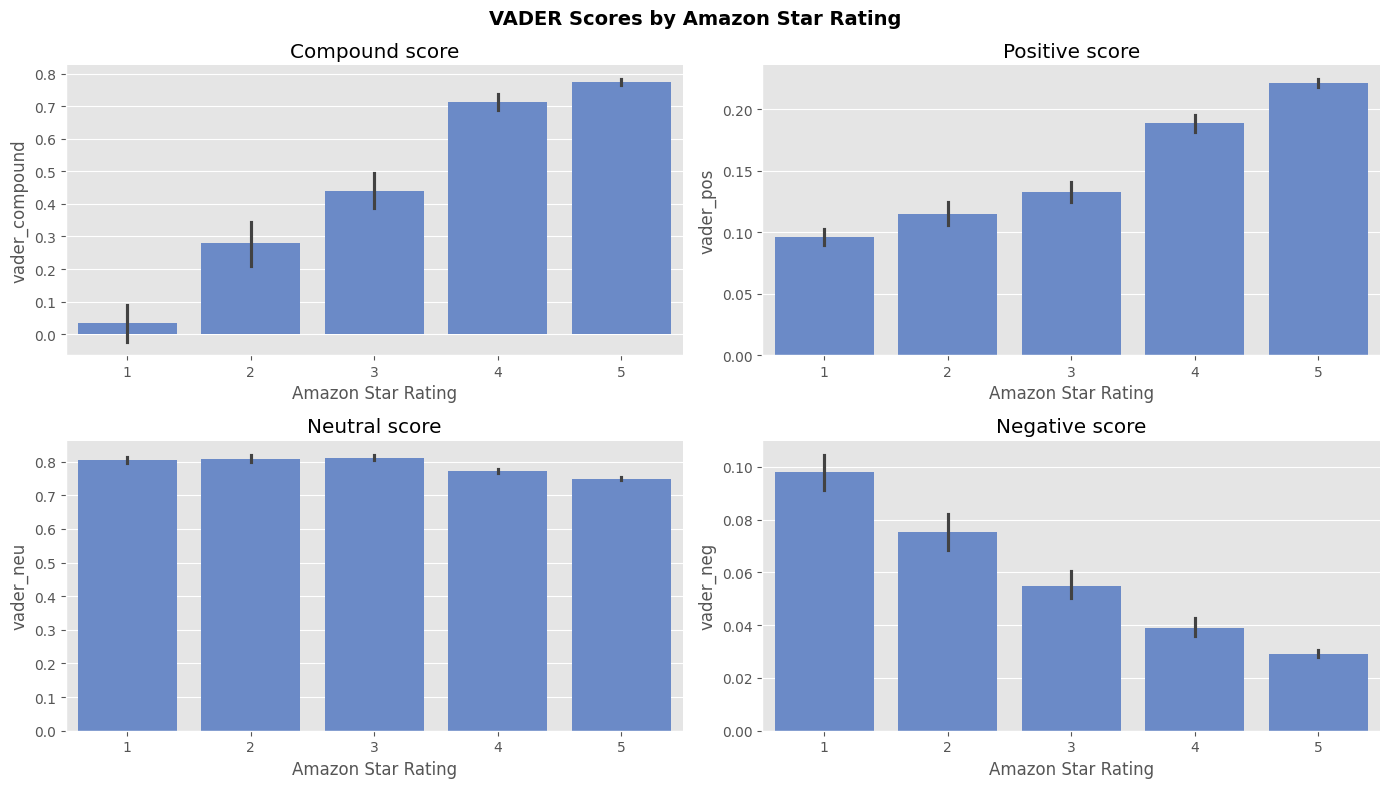

In [18]:
def plot_vader_scores(df: pd.DataFrame) -> None:
    """
    Reproduce original notebook cells 41–48.
    Bar plots of compound / pos / neu / neg by star rating.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle("VADER Scores by Amazon Star Rating", fontsize=14, fontweight="bold")

    for ax, col, title in zip(
        axes.flat,
        ["vader_compound", "vader_pos", "vader_neu", "vader_neg"],
        ["Compound score", "Positive score", "Neutral score", "Negative score"],
    ):
        sns.barplot(data=df, x="Score", y=col, ax=ax, color=C["bar"])
        ax.set_title(title)
        ax.set_xlabel("Amazon Star Rating")

    plt.tight_layout()
    plt.show()


plot_vader_scores(data)


## 6. RoBERTa Sentiment Scoring
Transformer-based model (`cardiffnlp/twitter-roberta-base-sentiment`).
Scores reviews with softmax probabilities → argmax → label.

Original notebook cells 52–53 / 59–62 / 94–96.  
Maps to Airflow task: `score_roberta()`

> **Note:** texts longer than 512 tokens are truncated — the model's hard limit.


In [19]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
import torch


def load_roberta(model_name: str = CONFIG["roberta_model"]):
    """
    Load RoBERTa tokenizer and model (original notebook cell 53).
    Returns (tokenizer, model) tuple — kept separate from scoring
    so the model is loaded once and reused.
    """
    logger.info(f"Loading RoBERTa model: {model_name}")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    model.eval()
    logger.info("RoBERTa model loaded.")
    return tokenizer, model


def _score_single_roberta(text: str, tokenizer, model,
                           max_len: int = CONFIG["roberta_max_len"]) -> dict:
    """
    Score one text with RoBERTa. Returns neg/neu/pos probabilities.
    Adapted from original notebook cell 59 — adds truncation to avoid
    RuntimeError on long reviews.
    """
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_len,
    )
    with torch.no_grad():
        output = model(**encoded)
    probs = softmax(output.logits[0].numpy())
    return {
        "roberta_neg": float(probs[0]),
        "roberta_neu": float(probs[1]),
        "roberta_pos": float(probs[2]),
    }


# ── Label mapping identical to original notebook cell 95 ──────────────────────
_ROBERTA_COL_TO_LABEL = {
    "roberta_neg": "Negative",
    "roberta_neu": "Neutral",
    "roberta_pos": "Positive",
}


def score_roberta(df: pd.DataFrame, tokenizer, model) -> pd.DataFrame:
    """
    Run RoBERTa on every review text and add:
      - roberta_neg, roberta_neu, roberta_pos   (softmax probabilities)
      - Roberta_Prediction                       (Negative/Neutral/Positive)

    Original logic: cells 59–62 and 94–96.

    Args:
        df:        DataFrame with 'Text' column
        tokenizer: loaded from load_roberta()
        model:     loaded from load_roberta()
    Returns:
        df with RoBERTa columns appended
    """
    logger.info("Running RoBERTa on all reviews (this may take a while)...")

    results = []
    for text in tqdm(df["Text"], total=len(df), desc="RoBERTa"):
        try:
            results.append(_score_single_roberta(str(text), tokenizer, model))
        except Exception as e:
            logger.warning(f"Skipping row — error: {e}")
            results.append({"roberta_neg": None, "roberta_neu": None, "roberta_pos": None})

    roberta_scores = pd.DataFrame(results, index=df.index)
    df = pd.concat([df, roberta_scores], axis=1)

    # Argmax → label (original notebook cell 95)
    df["Roberta_Prediction"] = (
        df[["roberta_neg", "roberta_neu", "roberta_pos"]]
        .idxmax(axis=1)
        .map(_ROBERTA_COL_TO_LABEL)
    )

    logger.info(f"RoBERTa predictions:\n{df['Roberta_Prediction'].value_counts().to_string()}")
    return df


In [20]:
# ── Run ──────────────────────────────────────────────────────────────────────
roberta_tokenizer, roberta_model = load_roberta(CONFIG["roberta_model"])
data = score_roberta(data, roberta_tokenizer, roberta_model)
data[["Text", "Score", "True_label", "Roberta_Prediction"]].head(8)


20:22:17 | INFO | Loading RoBERTa model: cardiffnlp/twitter-roberta-base-sentiment
20:22:17 | INFO | HTTP Request: HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:22:17 | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cardiffnlp/twitter-roberta-base-sentiment/daefdd1f6ae931839bce4d0f3db0a1a4265cd50f/config.json "HTTP/1.1 200 OK"
20:22:17 | INFO | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/cardiffnlp/twitter-roberta-base-sentiment/daefdd1f6ae931839bce4d0f3db0a1a4265cd50f/config.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

20:22:17 | INFO | HTTP Request: HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment/resolve/main/tokenizer_config.json "HTTP/1.1 404 Not Found"
20:22:17 | INFO | HTTP Request: HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment/resolve/main/tokenizer_config.json "HTTP/1.1 404 Not Found"
20:22:17 | INFO | HTTP Request: GET https://huggingface.co/api/models/cardiffnlp/twitter-roberta-base-sentiment/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
20:22:17 | INFO | HTTP Request: GET https://huggingface.co/api/models/cardiffnlp/twitter-roberta-base-sentiment/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
20:22:17 | INFO | HTTP Request: HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment/resolve/main/vocab.json "HTTP/1.1 307 Temporary Redirect"
20:22:17 | WARNING | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faste

vocab.json: 0.00B [00:00, ?B/s]

20:22:17 | INFO | HTTP Request: HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment/resolve/main/merges.txt "HTTP/1.1 307 Temporary Redirect"
20:22:17 | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cardiffnlp/twitter-roberta-base-sentiment/daefdd1f6ae931839bce4d0f3db0a1a4265cd50f/merges.txt "HTTP/1.1 200 OK"
20:22:17 | INFO | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/cardiffnlp/twitter-roberta-base-sentiment/daefdd1f6ae931839bce4d0f3db0a1a4265cd50f/merges.txt "HTTP/1.1 200 OK"


...

RoBERTa:   0%|          | 0/5000 [00:00<?, ?it/s]

20:22:24 | INFO | HTTP Request: GET https://huggingface.co/api/models/cardiffnlp/twitter-roberta-base-sentiment/xet-read-token/5ecd13590450ab163e43547492b0cfc49f16629b "HTTP/1.1 200 OK"


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

20:32:37 | INFO | RoBERTa predictions:
Roberta_Prediction
Positive    3872
Negative     785
Neutral      343


,Text,Score,True_label,Roberta_Prediction
0,I have bought several of the Vitality canned d...,5,Positive,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,Negative,Negative
2,This is a confection that has been around a fe...,4,Positive,Positive
3,If you are looking for the secret ingredient i...,2,Negative,Positive
4,Great taffy at a great price. There was a wid...,5,Positive,Positive
5,I got a wild hair for taffy and ordered this f...,4,Positive,Positive
6,This saltwater taffy had great flavors and was...,5,Positive,Positive
7,This taffy is so good. It is very soft and ch...,5,Positive,Positive


## 7. Evaluation
Full classification report + confusion matrices + F1 bar chart.
Both models evaluated against the assignment 3-class target.

Maps to Airflow task: `evaluate_models()`


In [21]:
CLASSES = ["Negative", "Neutral", "Positive"]


def classification_reports(df: pd.DataFrame) -> dict:
    """
    Compute classification reports for VADER and RoBERTa.
    Returns dict with keys 'vader' and 'roberta' (dict format for serialisation).
    Adapted from original notebook cells 99–100 / 108.
    """
    report_vader   = classification_report(df["True_label"], df["Vader_Prediction"],
                                           labels=CLASSES, output_dict=True, zero_division=0)
    report_roberta = classification_report(df["True_label"], df["Roberta_Prediction"],
                                           labels=CLASSES, output_dict=True, zero_division=0)

    logger.info("\n--- VADER Classification Report ---")
    logger.info("\n" + classification_report(df["True_label"], df["Vader_Prediction"],
                                              labels=CLASSES, zero_division=0))
    logger.info("\n--- RoBERTa Classification Report ---")
    logger.info("\n" + classification_report(df["True_label"], df["Roberta_Prediction"],
                                              labels=CLASSES, zero_division=0))
    return {"vader": report_vader, "roberta": report_roberta}


def plot_confusion_matrix(y_true, y_pred, title: str) -> None:
    """
    Plot a labelled confusion matrix. Original notebook cell 103.
    """
    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(title)
    plt.ylabel("Actual (Amazon Score)")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


def plot_f1_comparison(reports: dict) -> None:
    """
    F1-score bar chart — VADER vs RoBERTa per class.
    Original notebook cells 108–109.
    """
    f1_data = {
        "Class":   CLASSES,
        "VADER":   [reports["vader"][c]["f1-score"]   for c in CLASSES],
        "RoBERTa": [reports["roberta"][c]["f1-score"] for c in CLASSES],
    }
    df_melted = pd.DataFrame(f1_data).melt(id_vars="Class", var_name="Model", value_name="F1")

    plt.figure(figsize=(9, 5))
    sns.barplot(data=df_melted, x="Class", y="F1", hue="Model",
                palette=["#3498db", "#2ecc71"])
    plt.title("Performance Comparison: VADER vs RoBERTa (F1-Score)",
              fontsize=14, fontweight="bold")
    plt.ylim(0, 1.1)
    plt.ylabel("F1-Score")
    plt.xlabel("Sentiment Class")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()


def evaluate_models(df: pd.DataFrame) -> dict:
    """
    Full evaluation: reports + confusion matrices + F1 chart.
    Entry point for Airflow task.

    Returns:
        reports dict (serialisable)
    """
    reports = classification_reports(df)
    plot_confusion_matrix(df["True_label"], df["Vader_Prediction"],   "VADER Confusion Matrix")
    plot_confusion_matrix(df["True_label"], df["Roberta_Prediction"], "RoBERTa Confusion Matrix")
    plot_f1_comparison(reports)
    return reports


20:32:38 | INFO | 
--- VADER Classification Report ---
20:32:38 | INFO | 
              precision    recall  f1-score   support

    Negative       0.58      0.41      0.48       759
     Neutral       0.18      0.05      0.08       395
    Positive       0.84      0.95      0.89      3846

    accuracy                           0.80      5000
   macro avg       0.53      0.47      0.48      5000
weighted avg       0.75      0.80      0.76      5000

20:32:38 | INFO | 
--- RoBERTa Classification Report ---
20:32:38 | INFO | 
              precision    recall  f1-score   support

    Negative       0.72      0.75      0.73       759
     Neutral       0.24      0.21      0.22       395
    Positive       0.93      0.93      0.93      3846

    accuracy                           0.85      5000
   macro avg       0.63      0.63      0.63      5000
weighted avg       0.84      0.85      0.85      5000



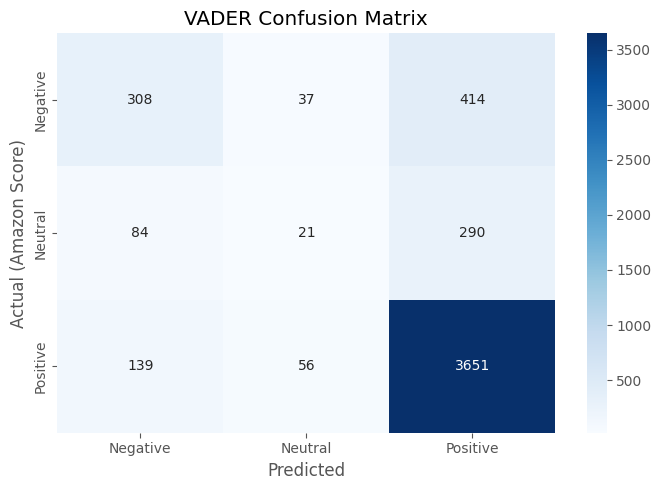

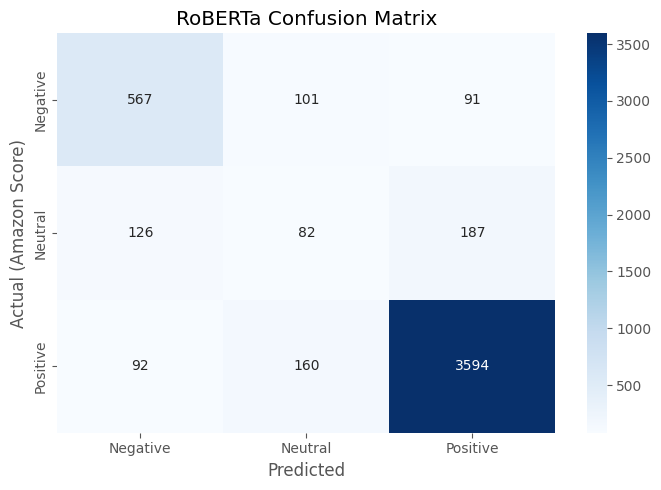

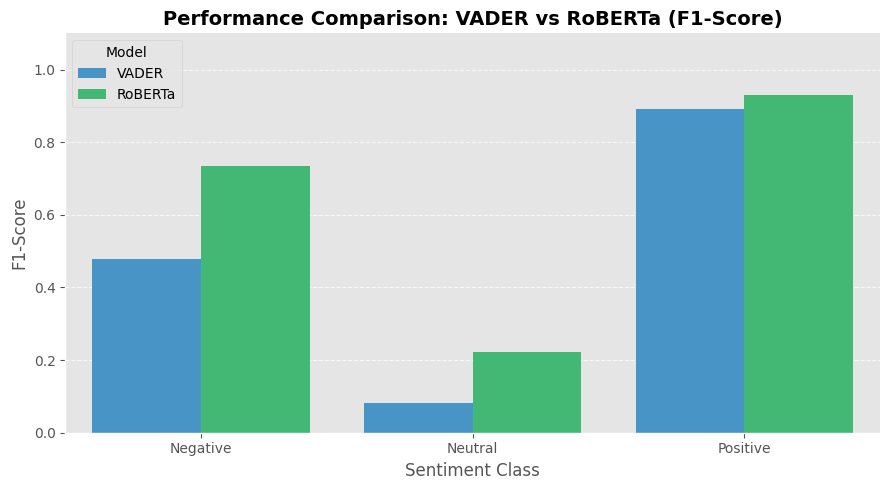

In [22]:
# ── Run ──────────────────────────────────────────────────────────────────────
reports = evaluate_models(data)


## 8. Saving Artefacts
Persist the scored DataFrame and JSON reports for downstream use
(e.g. MLflow logging, Airflow XCom, Metabase).

Maps to Airflow task: `save_artifacts()`


In [23]:
def save_artifacts(df: pd.DataFrame, reports: dict,
                   results_path: str  = CONFIG["results_path"],
                   report_vader_path: str  = CONFIG["report_vader_path"],
                   report_roberta_path: str = CONFIG["report_roberta_path"]) -> None:
    """
    Save:
      - results_df.csv       : full scored DataFrame
      - report_vader.json    : VADER classification report
      - report_roberta.json  : RoBERTa classification report

    Args:
        df:                  scored DataFrame
        reports:             dict from evaluate_models()
        *_path:              output file paths (from CONFIG)
    """
    df.to_csv(results_path, index=False)
    logger.info(f"Results saved → {results_path}  ({len(df):,} rows)")

    with open(report_vader_path, "w") as f:
        json.dump(reports["vader"], f, indent=2)
    logger.info(f"VADER report saved → {report_vader_path}")

    with open(report_roberta_path, "w") as f:
        json.dump(reports["roberta"], f, indent=2)
    logger.info(f"RoBERTa report saved → {report_roberta_path}")


In [24]:
# ── Run ──────────────────────────────────────────────────────────────────────
save_artifacts(data, reports)


20:32:38 | INFO | Results saved → results_df.csv  (5,000 rows)
20:32:38 | INFO | VADER report saved → report_vader.json
20:32:38 | INFO | RoBERTa report saved → report_roberta.json
